In [32]:
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph import StateGraph,START,END
from langgraph.graph.message import add_messages


In [33]:
class State(TypedDict):
    messages: Annotated[list,add_messages]


import os
from dotenv import load_dotenv
load_dotenv()

if os.getenv("OPENAI_API_KEY") is None:
    raise ValueError("OPENAI_API_KEY environment variable not set")



In [34]:
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(model="gpt-4o-mini", temperature=0.9)


In [35]:
def chatbot(state: State) -> State:
    if state is START:
        return {"messages":[{"role":"system","content":"You are a helpful assistant."}]}
    elif state is END:
        return END
    else:
        response = llm.invoke(state["messages"])
        return {"messages": state["messages"] + [response]}

In [36]:

graph_builder = StateGraph(State)
graph_builder.add_node("chatbot",chatbot)

graph_builder.add_edge(START,"chatbot")
graph_builder.add_edge("chatbot",END)

graph= graph_builder.compile()

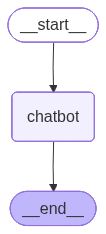

In [37]:
from IPython.display import Image,display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception as e:
    print("Graph visualization is not supported in this environment.")

In [38]:
response = graph.invoke({"messages": [{"role": "user", "content": "Hi"}]})
response["messages"][-1].content

'Hello! How can I assist you today?'

In [39]:
for event in graph.stream({"messages": [{"role": "user", "content": "Hi"}]}):
    print(event)

{'chatbot': {'messages': [HumanMessage(content='Hi', additional_kwargs={}, response_metadata={}, id='d525fd91-893c-43dd-8bd9-83396565037b'), AIMessage(content='Hello! How can I assist you today?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 9, 'prompt_tokens': 8, 'total_tokens': 17, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_8f1fc3349c', 'id': 'chatcmpl-DUEPI0rYuOe0DGI6cH7qKhjz9yWrT', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019d87aa-7f44-7fe0-84c5-c23ddfd1e403-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 8, 'output_tokens': 9, 'total_tokens': 17, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_d

In [40]:
# multiply 2 numbers
def multiply(a, b):
    """Multiplies two numbers and returns the result."""

    print("Multiplying", a, "and", b)
    return a * b

# add 2 numbers
def add(a, b):
    """Adds two numbers and returns the result."""

    print("Adding", a, "and", b)
    return a + b

tools = [multiply,add]
llm_with_tools =llm.bind_tools(tools)

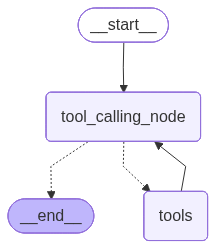

In [53]:
from langgraph.prebuilt import ToolNode,tools_condition
from langgraph.checkpoint.memory import MemorySaver

memory = MemorySaver()

def tool_calling_llm(state: State):
    return {"messages": [llm_with_tools.invoke(state["messages"])]}

builder= StateGraph(State)
builder.add_node("tools",ToolNode(tools))
builder.add_node("tool_calling_node",tool_calling_llm)

builder.add_edge(START,"tool_calling_node")
builder.add_conditional_edges("tool_calling_node",tools_condition)
builder.add_edge( "tools","tool_calling_node")

graph = builder.compile(checkpointer=memory)
display(Image(graph.get_graph().draw_mermaid_png()))


In [51]:
response = graph.invoke({"messages":[{"role":"user","content":"What is 5 plus 3 and 5 multiplied by 5?"}]})
print(response["messages"][-1].content)

AddingMultiplying 5 and 5
 5 and 3
5 plus 3 is 8, and 5 multiplied by 5 is 25.


In [60]:
config={"configurable":{"thread_id":"1"}}
response = graph.invoke({"messages":[{"role":"user","content":"Hi My name is daniyal. give me a nickname. dont give me options, just give me a nickname and save it"}]},config=config)
print(response["messages"][-1].content)



Your nickname is "Dani."


In [65]:
response = graph.invoke({"messages":[{"role":"user","content":"change my nickname to dany"}]},config=config)
print(response["messages"][-1].content)

Your nickname is now changed to "Dany."


In [67]:
response = graph.invoke({"messages":[{"role":"user","content":"what was the old nickname?"}]},config=config)
print(response["messages"][-1].content)

Your old nickname was "Dani."


In [69]:
from langgraph.checkpoint.memory import MemorySaver
memory = MemorySaver()

def superbot(state: State):
    return {"messages": [llm.invoke(state["messages"])]}

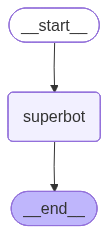

Hi Daniyal! That’s great to hear! MotoGP is an exciting sport with a rich history and some incredible riders. Do you have a favorite team or rider? Or is there a particular aspect of MotoGP that you enjoy the most?


In [ ]:
#create a graph with superbot as the only node and memory as the checkpointer 
builder2= StateGraph(State)
builder2.add_node("superbot",superbot)
builder2.add_edge(START,"superbot")
builder2.add_edge("superbot",END)

graph2 = builder2.compile(checkpointer=memory)
display(Image(graph2.get_graph().draw_mermaid_png()))

config={"configurable":{"thread_id":"1"}}
response = graph2.invoke({"messages":[{"role":"user","content":"Hi My name is daniyal and i like motogp"}]}, config)
print(response["messages"][-1].content)



In [74]:
config = {"configurable":{"thread_id":"3"}}

for chunk in graph2.stream({"messages":[{"role":"user","content":"Hi My name is daniyal and i like motogp"}]},config=config, stream_mode="updates"):
    print(chunk)

{'superbot': {'messages': [AIMessage(content="Hi Daniyal! It's great to hear that you enjoy MotoGP. Do you have a favorite rider or team? Or is there a specific aspect of MotoGP that you find most exciting?", additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 38, 'prompt_tokens': 20, 'total_tokens': 58, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_8f1fc3349c', 'id': 'chatcmpl-DUF6lN3zsY9chBMS6XMZ0uOtN6nym', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019d87d3-9e7b-7893-a3ab-d80b6d9a7776-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 20, 'output_tokens': 38, 'total_tokens': 58, 'input_token_details': {'audio': 0, 'cache_read': 0},

In [77]:
config = {"configurable":{"thread_id":"3"}}

for chunk in graph2.stream({"messages":[{"role":"user","content":"Hi My name is daniyal and i like motogp"}]},config=config, stream_mode="values"):
    print(chunk)

{'messages': [HumanMessage(content='Hi My name is daniyal and i like motogp', additional_kwargs={}, response_metadata={}, id='13adfaa2-af19-40aa-b5e9-1d85da41e8d2'), AIMessage(content="Hi Daniyal! It's great to hear that you enjoy MotoGP. Do you have a favorite rider or team? Or is there a specific aspect of MotoGP that you find most exciting?", additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 38, 'prompt_tokens': 20, 'total_tokens': 58, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_8f1fc3349c', 'id': 'chatcmpl-DUF6lN3zsY9chBMS6XMZ0uOtN6nym', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019d87d3-9e7b-7893-a3ab-d80b6d9a7776-0', tool_calls=[], invalid_tool_c

In [83]:
config = {"configurable":{"thread_id":"6"}}

for chunk in graph2.stream({"messages":[{"role":"user","content":"\nHi My name is daniyal and i like motogp\n"}]},config=config, stream_mode="updates"):
    print(chunk)

{'superbot': {'messages': [AIMessage(content="Hi Daniyal! It's awesome to hear that you like MotoGP. Who's your favorite rider or team? Do you have a favorite race or moment from the season?", additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 34, 'prompt_tokens': 76, 'total_tokens': 110, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_8f1fc3349c', 'id': 'chatcmpl-DUF9qeVKcJGZWqb7H5p1pJj7CBBje', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019d87d6-8c5e-7f12-9b63-7b03c913c53d-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 76, 'output_tokens': 34, 'total_tokens': 110, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token